# **11장. 합성곱 신경망 모델 구현**

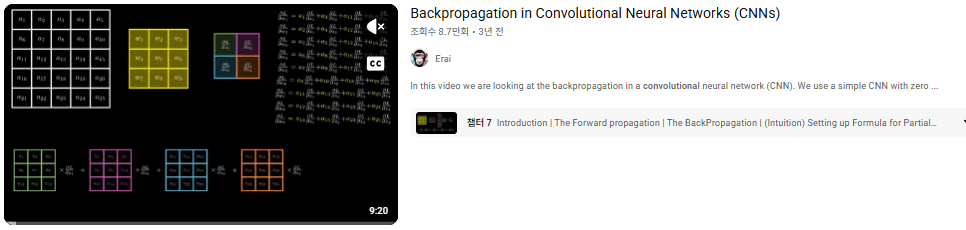

https://www.youtube.com/watch?v=z9hJzduHToc

이 동영상은 CNN 모델의 역전파 과정에서 필터값 파라미터가 업데이트되는 과정을 잘 설명하고 있습니다.


---




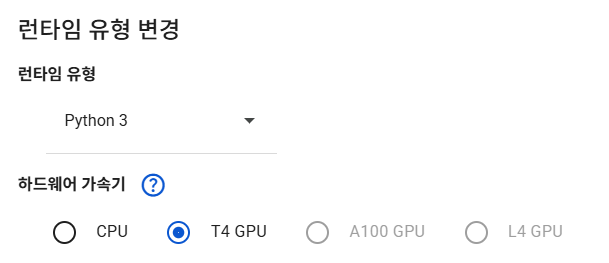

* CNN은 파라미터가 많아서 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.
* 코랩 메뉴에서 [런타임 --> 유형변경]을 클릭하고 하드웨어 가속기를 T4 GPU로 바꾸어 실행해봅시다.
> 이 책에서는 필요한 노트북의 런타임을 T4 GPU로 미리 설정해 두었습니다.
* 단 무료 버전의 GPU 런타임은 실행 시간이 정해져 있으며, 시간대에 따라 접속이 안될 경우도 있습니다.

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
from tensorflow.keras.datasets import cifar10
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

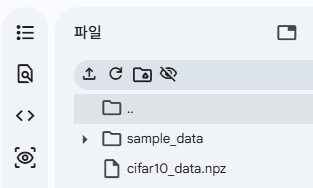

실습 파일(165mega bytes)은 출판사 자료실에서 다운로드 가능합니다.

* *.npz는 여러 개의 배열 데이터를 하나의 압축 파일로 저장하는 파일 유형입니다
* np.load() 함수를 사용해서 불러올 수 있습니다.
* 큰 데이터이므로 시간이 좀 걸릴 수 있습니다.

[실습 11-01]

In [ ]:
df=np.load('cifar10_data.npz')

x_train = df['x_train']; y_train = df['y_train']
x_test = df['x_test']; y_test = df['y_test']

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)


cifar10 데이터를 **온라인**으로 불러오는 방법은 **노트북_11장(A).ipynb**를 참조하세요.
* 가끔 네트워크 문제로 온라인 업로드에 시간이 많이 소요되는 문제가 있어, 책은 npz 압축 파일을 로컬에서 사용하는 방법으로 설명하였습니다.
* 대용량 파일을 다루는데 문제가 있을 경우엔 **노트북_11장(A).ipynb**를 대신 사용해도 좋습니다.   
> 단 데이터 배열 순서가 압축 파일과 약간 다르므로, 일부 결과가 조금 달라질 수 있습니다.

[실습 11-02]

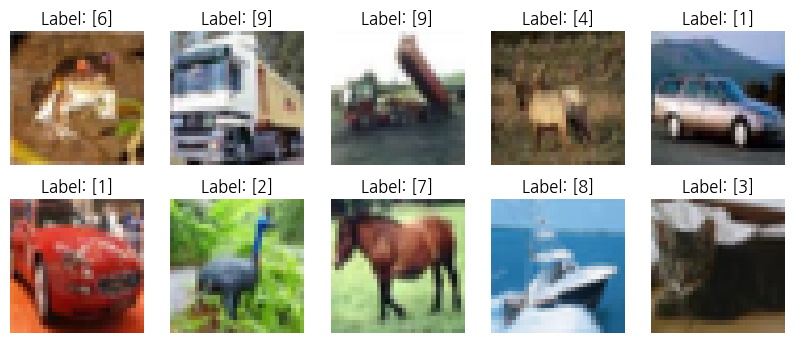

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)  # 2행 5열의 서브플롯
    plt.imshow(x_train[i])
    plt.axis("off")  # 축 숨기기
    plt.title(f"Label: {y_train[i]}")

plt.show()

[실습 11-03]

In [ ]:
# 좌우 반전된 데이터를 원본 뒤에 붙이기
x_train_flipped = np.flip(x_train, axis=2)
x_train = np.concatenate([x_train, x_train_flipped], axis=0)
y_train = np.concatenate([y_train, y_train], axis=0)

# 데이터 크기 확인(2배로 증가)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (100000, 32, 32, 3)
y_train shape: (100000, 1)


[실습 11-04]

In [ ]:
x_train=x_train/255; x_test=x_test/255 # 스케일 정규화

class_labels=['air','auto','bird','cat','deer','dog','frog','horse','ship','truck']

* 정규화는 반드시 한번만 이루어져야 합니다. 실수로 위 코드를 중복 실행하면 값들이 모두 0에 가까워져 학습이 되지 않습니다.  

[실습 11-05]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

CIFAR=Sequential([
    Input(shape=(32,32,3)),
# Block 1
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='elu'), # filters= 과 kernel_size= 는 생략 가능(순서 주의)
    Conv2D(32, (3,3), padding='same', activation='elu'),
    MaxPooling2D(pool_size=(2, 2)),   # pool_size는 (2,2)가 기본, 생략 가능
    Dropout(0.2),
# Block 2
    Conv2D(64, (3,3), padding='same', activation='elu'),
    Conv2D(64, (3,3), padding='same', activation='elu'),
    MaxPooling2D(),
    Dropout(0.3),
# Block 3
    Conv2D(128, (3,3), padding='same', activation='elu'),
    MaxPooling2D(),
    Dropout(0.4),

# Dense 층으로 연결
    GlobalAveragePooling2D(),
    Dense(128, activation='elu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
    ])

CIFAR.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,226 (614.16 KB)

 Trainable params: 157,226 (614.16 KB)

 Non-trainable params: 0 (0.00 B)

[참고]

CNN은 기본적으로 선형 함수이므로 비선형 활성화 함수가 필요하고 보통 elu를 사용한다.

elu(x)는
* x가 0 이상일때는 그대로 x (relu와 같음)
* x가 0보다 작으면 exp(x)-1 (relu에서는 0)

elu(x)는 x의 모든 값에서 연속적으로 변화하므로 학습이 안정적이고 그만큼 성과가 좋은 것으로 알려져 있다.
* 물론 relu도 사용 가능하다.   


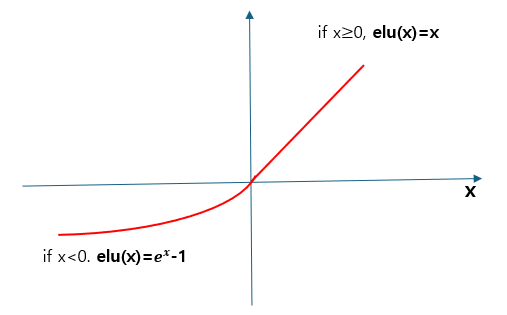

[실습 11-06]

In [ ]:
early_stop=EarlyStopping(monitor="val_loss",
                         patience=5, restore_best_weights=True )

CIFAR.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history=CIFAR.fit(x_train, y_train,
                  validation_data=(x_test, y_test), epochs=100,
                  callbacks=[early_stop])

Epoch 1/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.4731 - loss: 1.4429 - val_accuracy: 0.6255 - val_loss: 1.0328
Epoch 2/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6174 - loss: 1.0798 - val_accuracy: 0.6818 - val_loss: 0.8835
Epoch 3/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.6643 - loss: 0.9566 - val_accuracy: 0.7255 - val_loss: 0.7849
Epoch 4/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6968 - loss: 0.8682 - val_accuracy: 0.7627 - val_loss: 0.6766
Epoch 5/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7187 - loss: 0.8102 - val_accuracy: 0.7861 - val_loss: 0.6233
Epoch 6/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7348 - loss: 0.7678 - val_accuracy: 0.7947 - val_loss: 0.6059
Epoch 7/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7461 - loss: 0.7370 - val_accuracy: 0.8038 - val_loss: 0.5717
Epoch 8/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7565 -

[실습 11-07]

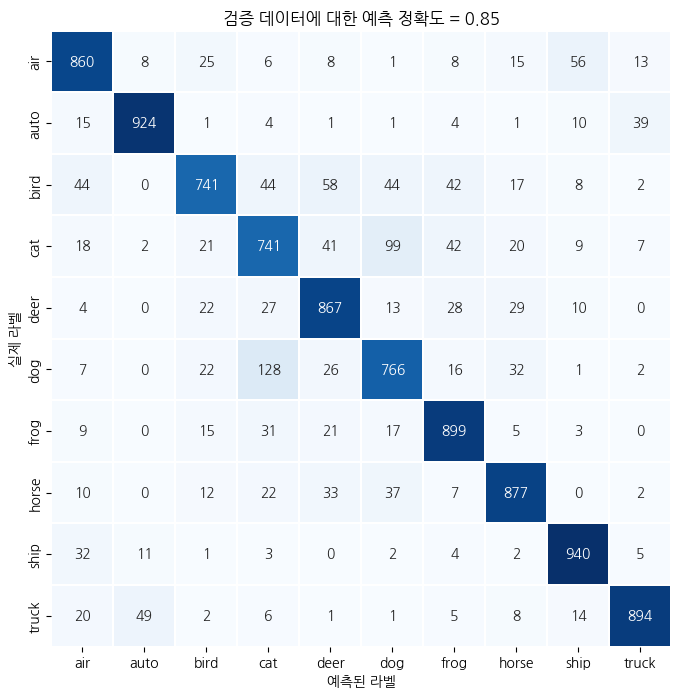

In [ ]:
import seaborn as sns
y_prob=CIFAR.predict(x_test, verbose=0)  # 클래스별 확률 예측
y_pred=np.argmax(y_prob, axis=1)         # max 확률 인덱스

# 검증용 데이터셋에 대한 혼동행렬 생성
cm=confusion_matrix(y_test, y_pred)
# 분류 정확도 계산
acc=accuracy_score(y_test, y_pred)

# 혼동 행렬 시각화 (이전 코드 재활용)
plt.figure(figsize=(8, 8))

sns.heatmap(cm, annot=True,fmt="d", linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)

plt.ylabel('실제 라벨'); plt.xlabel('예측된 라벨')
plt.title(f"검증 데이터에 대한 예측 정확도 = {acc:.2f}")
plt.show()

[실습 11-08]

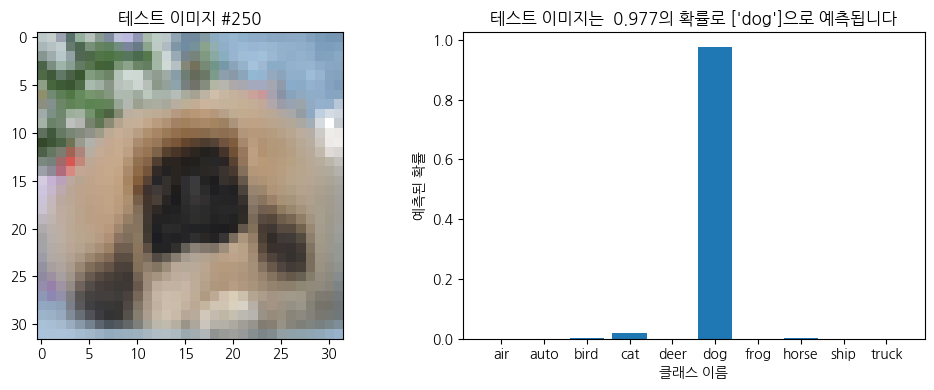

In [ ]:
#테스트 이미지 분류 - 1
plt.figure(figsize=(10, 4)) # 그림 크기
k=250    # 예측 이미지 선택

# 첫 번째 서브플롯: 이미지
plt.subplot(1, 2, 1)
plt.imshow(x_test[k])
plt.title(f"테스트 이미지 #{k}")
y_prob=CIFAR.predict(x_test, verbose=0)[k]  # 클래스별 예측 확률
y_pred=np.argmax(y_prob)                # 예측된 레이블(가장 높은 확률을 가진 클래스)
max_prob=np.max(y_prob)

# 두 번째 서브플롯: 예측 확률
plt.subplot(1, 2, 2)
plt.bar(class_labels, y_prob)
plt.xticks(np.arange(10))
plt.xlabel("클래스 이름")
plt.ylabel("예측된 확률")
plt.title(f"테스트 이미지는 {max_prob: .3f}의 확률로 {[class_labels[y_pred]]}으로 예측됩니다")
plt.tight_layout()
plt.show()

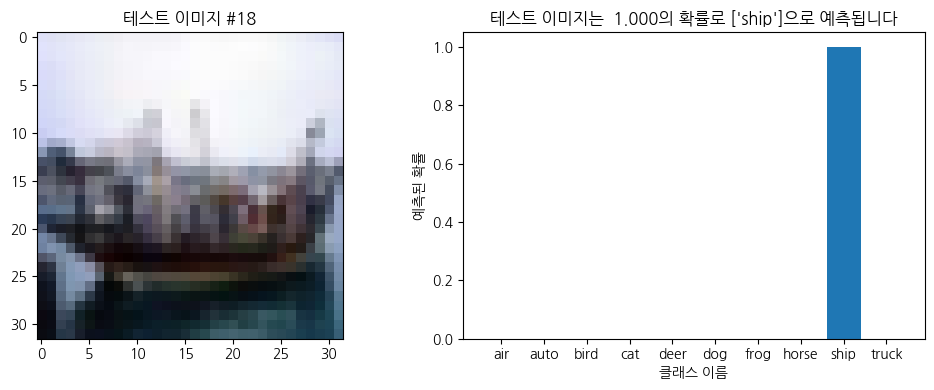

In [ ]:
#테스트 이미지 분류 - 2
plt.figure(figsize=(10, 4)) # 그림 크기
k=18    # 예측 이미지 선택
# 첫 번째 서브플롯: 이미지
plt.subplot(1, 2, 1)
plt.imshow(x_test[k])
plt.title(f"테스트 이미지 #{k}")
y_prob=CIFAR.predict(x_test, verbose=0)[k]  # 클래스별 예측 확률
y_pred=np.argmax(y_prob)                # 예측된 레이블(가장 높은 확률을 가진 클래스)
max_prob=np.max(y_prob)
# 두 번째 서브플롯: 예측 확률
plt.subplot(1, 2, 2)
plt.bar(class_labels, y_prob)
plt.xticks(np.arange(10))
plt.xlabel("클래스 이름")
plt.ylabel("예측된 확률")
plt.title(f"테스트 이미지는 {max_prob: .3f}의 확률로 {[class_labels[y_pred]]}으로 예측됩니다")
plt.tight_layout()
plt.show()

### **[더 알아보기]** 실제 학습된 레이어의 필터별 특성맵 시각화

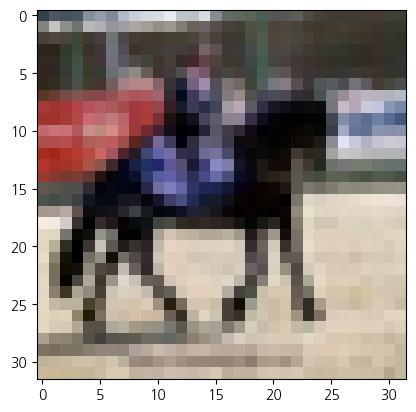

In [ ]:
# 테스트 이미지를 정합니다.
k=5000
plt.imshow(x_test[k])

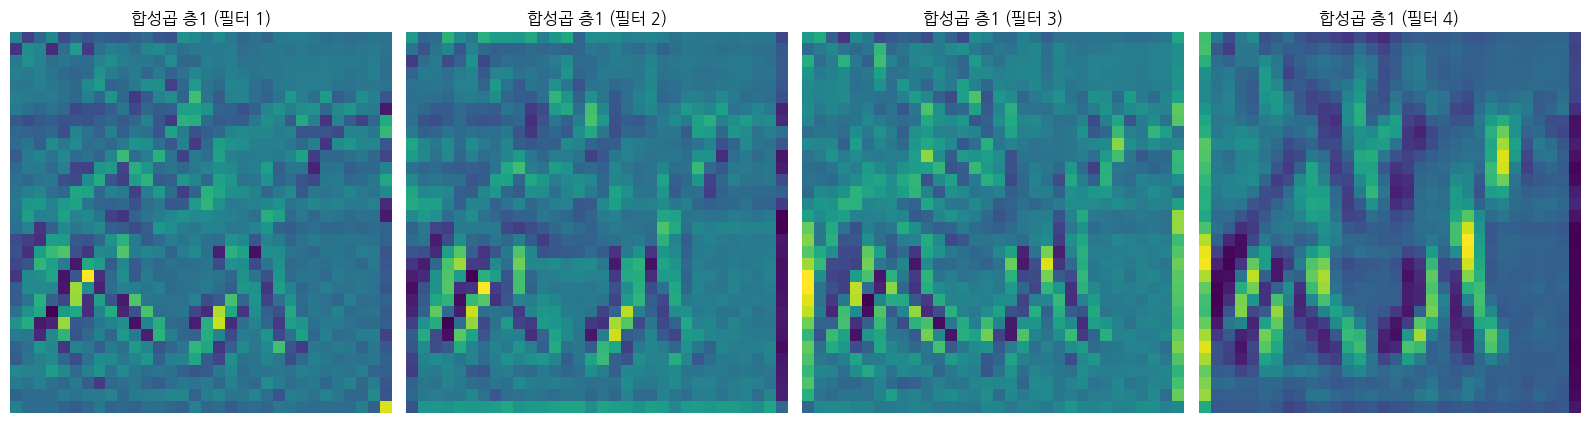

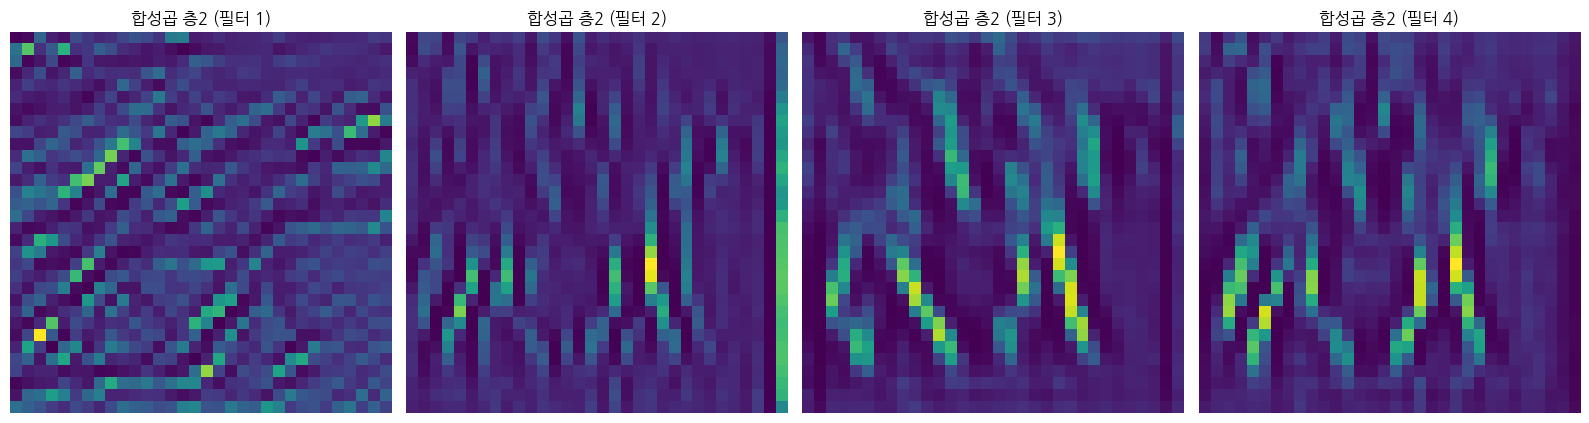

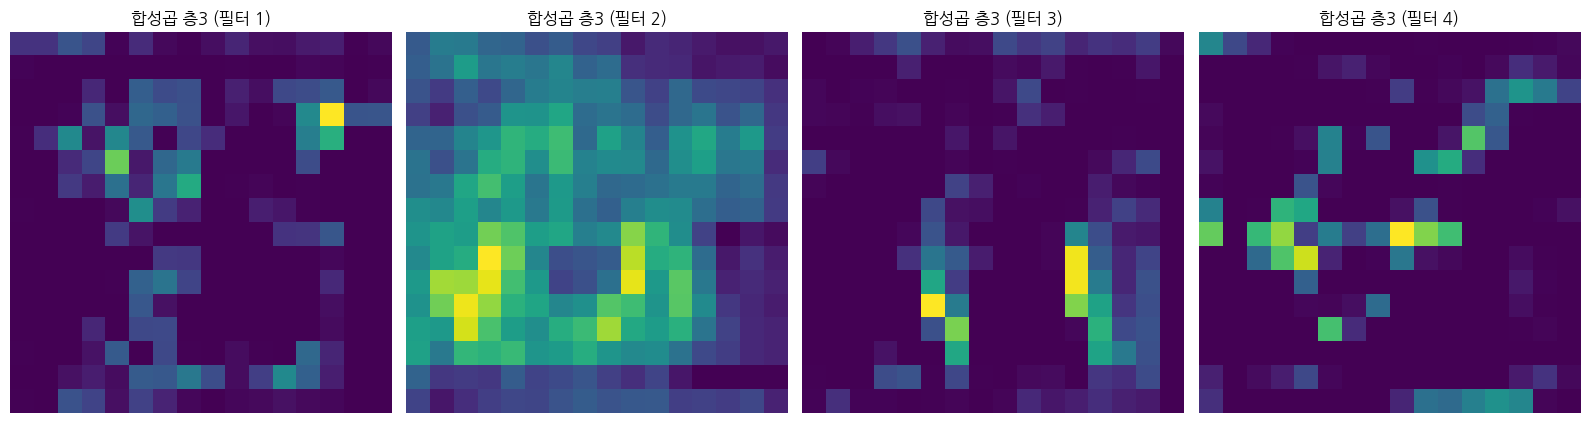

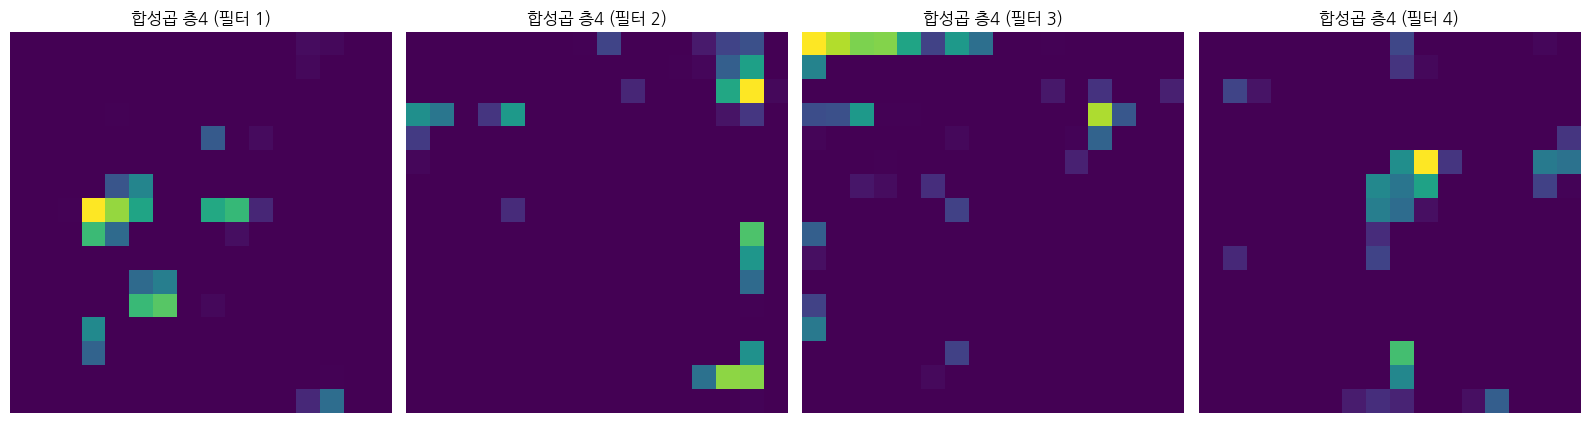

In [ ]:
# 1. 테스트 이미지를 4차원 텐서로 만들기
img = x_test[k:k+1]  # 모델 입력과 같은 (1, 32, 32, 3) 형태가 되어야 함

# 2. 특성맵을 담을 리스트와 현재 입력값 설정
activations = []
current_input = img

# 3, 모델의 레이어를 하나씩 순회하며 계산
for layer in CIFAR.layers:
    # 현재 레이어에 입력을 넣어 출력을 얻습니다.
    current_input = layer(current_input)
    # 만약 Conv2D 레이어라면 결과물(특성맵)을 저장합니다.
    if 'conv2d' in layer.name:
        activations.append(current_input.numpy()) # 텐서를 넘파이 배열로 변환

for layer in range(4):
# 4, 각 Conv2D 레이어의 특성맵 시각화
  current_layer_activation = activations[layer]
  plt.figure(figsize=(16, 14))
  for i in range(4): # 처음 4개의 필터 시각화
      plt.subplot(1, 4, i + 1)
      plt.imshow(current_layer_activation[0, :, :, i], cmap='viridis')
      plt.axis('off'); plt.tight_layout()
      plt.title(f"합성곱 층{layer+1} (필터 {i+1})")
plt.show()



---



### 원본 이미지의 디테일을 지우고 이런 압축된 특성만 사용해서 예측을 할 수 있다는게 신기하지 않나요?
* 여러분도 눈이나 걸음걸이만 보고 친구를 식별 가능하지 않나요?
* CNN은 사람의 시각지능을 모방한 것이랍니다.


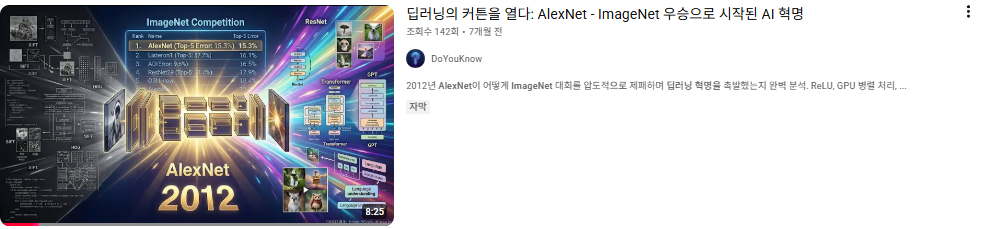

## https://www.youtube.com/watch?v=yco8Vv4ABmw


이 동영상은 **CNN**을 사용한 최초의 딥러닝 모델인 **AlexNet**이 세상을 바꾼 이야기를 들려줍니다.
-  **ReLU** 활성화 함수와 **드롭아웃**, **데이터 증강**이 사용되는 이유도 알 수 있습니다.